In [2]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt


In [15]:
# 使用者可修改以下參數，對應你的訓練輸出路徑
PLATFORM = 'CW308_STM32F4'
F = 'ChebyshevI'
FT = 'ChebyshevI_lowpass' #Butterworth ChebyshevI
CF = 700
CUTOFF_FREQ = '700K'  # 注意對應路徑中的命名，如 '1M' 或 '1M'（與程式儲存路徑一致）
# 根路徑：figure/train_mlp_order_compare/{PLATFORM}/{FT}/{CUTOFF_FREQ}/
root_dir = os.path.join('./figure/train_mlp_order_compare', PLATFORM, FT, CUTOFF_FREQ)

# 搜尋所有 order 資料夾下的 history.csv
pattern = os.path.join(root_dir, 'order*', 'history.csv')
file_paths = glob.glob(pattern)

if not file_paths:
    print(f"No history.csv files found under {root_dir}. 請確認路徑與命名正確。")
else:
    # 讀取所有 history.csv 到字典
    histories = {}
    for file_path in file_paths:
        # 從路徑擷取 order 編號
        m = re.search(r'order(\d+)', file_path)
        if m:
            order = int(m.group(1))
        else:
            # 若找不到 order 編號，可用完整路徑作鍵
            order = file_path
        try:
            df = pd.read_csv(file_path)
            # 如果 CSV 以 index_label='epoch' 儲存，可能有一欄 'epoch'
            # 確保 epoch 欄位存在，否則用 DataFrame 索引
            if 'epoch' in df.columns:
                # 有 epoch 欄位，並且通常 epoch 從 0 開始；若要從 1 開始繪圖，可 +1
                epochs = df['epoch'] + 1
            else:
                epochs = range(1, len(df) + 1)
            histories[order] = (epochs, df)
        except Exception as e:
            print(f"Warning: 無法讀取 {file_path}: {e}")

    # Plot Validation Accuracy
    plt.figure(figsize=(8, 6))
    # 設置跳刻度字體大小
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    for order in sorted(histories):
        epochs, df = histories[order]
        col_name = 'val_accuracy'
        if col_name in df.columns:
            plt.plot(epochs, df[col_name], label=f'Order {order}')
        else:
            print(f"Warning: {col_name} 不在 {order} 的 history.csv 中，跳過")
    plt.title(f'Validation Accuracy – {F} (Cutoff {CF} KHz)', fontsize=20)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.grid(True)
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    # 若需顯示圖表，可使用 plt.show()
    # plt.show()
    # 若需儲存，可指定存檔路徑
    save_dir = os.path.join(root_dir, 'compare_summary')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'val_acc_order_all2.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Validation accuracy plot saved to {save_path}")

Validation accuracy plot saved to ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/700K/compare_summary/val_acc_order_all2.png


In [14]:
import os
import glob
import re
import pandas as pd

# 使用者可修改以下參數，對應你的訓練輸出路徑
PLATFORM = 'CW308_STM32F4'
FT = 'ChebyshevI_lowpass'  # Butterworth ChebyshevI
CUTOFF_FREQ = '700K'  # 注意對應路徑中的命名，如 '1M' 或 '15M'（與程式儲存路徑一致）

# 根路徑：figure/train_mlp_order_compare/{PLATFORM}/{FT}/{CUTOFF_FREQ}/
root_dir = os.path.join('./figure/train_mlp_order_compare', PLATFORM, FT, CUTOFF_FREQ)

# 搜尋所有 order 資料夾下的 history.csv
pattern = os.path.join(root_dir, 'order*', 'history.csv')
file_paths = glob.glob(pattern)

results = []

if not file_paths:
    print(f"No history.csv files found under {root_dir}. 請確認路徑與命名正確。")
else:
    for file_path in file_paths:
        # 從路徑擷取 order 編號
        m = re.search(r'order(\d+)', file_path)
        if m:
            order = int(m.group(1))
        else:
            order = file_path
        try:
            df = pd.read_csv(file_path)
            if 'val_accuracy' in df.columns:
                # 計算最大 val_accuracy 與對應 index
                max_val = df['val_accuracy'].max()
                idx_max = df['val_accuracy'].idxmax()
                # 判斷 epoch 欄位是否存在
                if 'epoch' in df.columns:
                    epoch_at_max = int(df.loc[idx_max, 'epoch']) + 1
                else:
                    epoch_at_max = idx_max + 1
                # 轉換為百分比格式，保留兩位小數，如 99.85%
                max_val_pct = f"{max_val * 100:.1f}%"
                results.append({
                    'order': order,
                    'max_val_accuracy': max_val_pct,
                    'epoch_at_max': epoch_at_max,
                    'file_path': file_path
                })
            else:
                results.append({
                    'order': order,
                    'max_val_accuracy': None,
                    'epoch_at_max': None,
                    'file_path': file_path
                })
        except Exception as e:
            results.append({
                'order': order,
                'max_val_accuracy': None,
                'epoch_at_max': None,
                'file_path': file_path,
                'error': str(e)
            })

    # 建立 summary DataFrame
    df_summary = pd.DataFrame(results)
    # 嘗試根據 order 欄排序
    try:
        df_summary = df_summary.sort_values(by='order')
    except Exception:
        pass

    # 直接印出 summary
    if not df_summary.empty:
        # 使用 to_string 以完整列印 DataFrame
        print(df_summary.to_string(index=False))
    else:
        print("Summary 為空，可能所有檔案均無 val_accuracy 欄位或讀取失敗。")


 order max_val_accuracy  epoch_at_max                                                                                  file_path
     1           100.0%            33  ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order1/history.csv
     5            16.1%           254  ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order5/history.csv
    10            10.5%           215 ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order10/history.csv
    15            10.5%           175 ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order15/history.csv
    20             9.8%           156 ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order20/history.csv
    25             9.5%           187 ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_lowpass/500K/order25/history.csv
    30             9.3%           150 ./figure/train_mlp_order_compare/CW308_STM32F4/ChebyshevI_l

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 使用者可修改以下參數
PLATFORM = 'CW308_STM32F4'
ORDER = 5  # 固定階數

# 濾波器設定：key 為顯示名稱，value 為資料夾名稱
filters = {
    'Butterworth': 'Butterworth_lowpass',
    'ChebyshevI': 'ChebyshevI_lowpass'
}

# 倒序：從 1000K 到 500K
cutoff_folders = ['1000K', '900K', '800K', '700K', '600K', '500K']
cutoff_values  = [1000,    900,    800,    700,    600,    500]

plt.figure(figsize=(9, 6))  # 加寬一點，留出圖例空間
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

for f_name, ft in filters.items():
    for cf_val, cf_folder in zip(cutoff_values, cutoff_folders):
        hist_path = os.path.join(
            './figure/train_mlp_order_compare',
            PLATFORM,
            ft,
            cf_folder,
            f'order{ORDER}',
            'history.csv'
        )
        if not os.path.isfile(hist_path):
            print(f"Warning: 找不到 {f_name} {cf_val}KHz order{ORDER} 的 history.csv")
            continue

        df = pd.read_csv(hist_path)
        epochs = df['epoch'] + 1 if 'epoch' in df.columns else range(1, len(df) + 1)

        if 'val_accuracy' in df.columns:
            plt.plot(epochs, df['val_accuracy'], label=f'{f_name} {cf_val} KHz')
        else:
            print(f"Warning: {hist_path} 中沒有 val_accuracy 欄")

plt.title(f'Validation Accuracy – Order {ORDER}', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Validation Accuracy', fontsize=20)
plt.grid(True)

# 圖例放在右側圖框外
plt.tight_layout(rect=[0, 0, 0.85, 1])  # 留出 15% 空間給圖例
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.,
    fontsize=10
)

# 儲存比較圖
save_dir = os.path.join(
    './figure/train_mlp_order_compare',
    PLATFORM,
    f'compare_order{ORDER}'
)
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'val_acc_butter_vs_cheby_cutoff_1000_500.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.close()

print(f"Comparison plot saved to {save_path}")


Comparison plot saved to ./figure/train_mlp_order_compare/CW308_STM32F4/compare_order5/val_acc_butter_vs_cheby_cutoff_1000_500.png


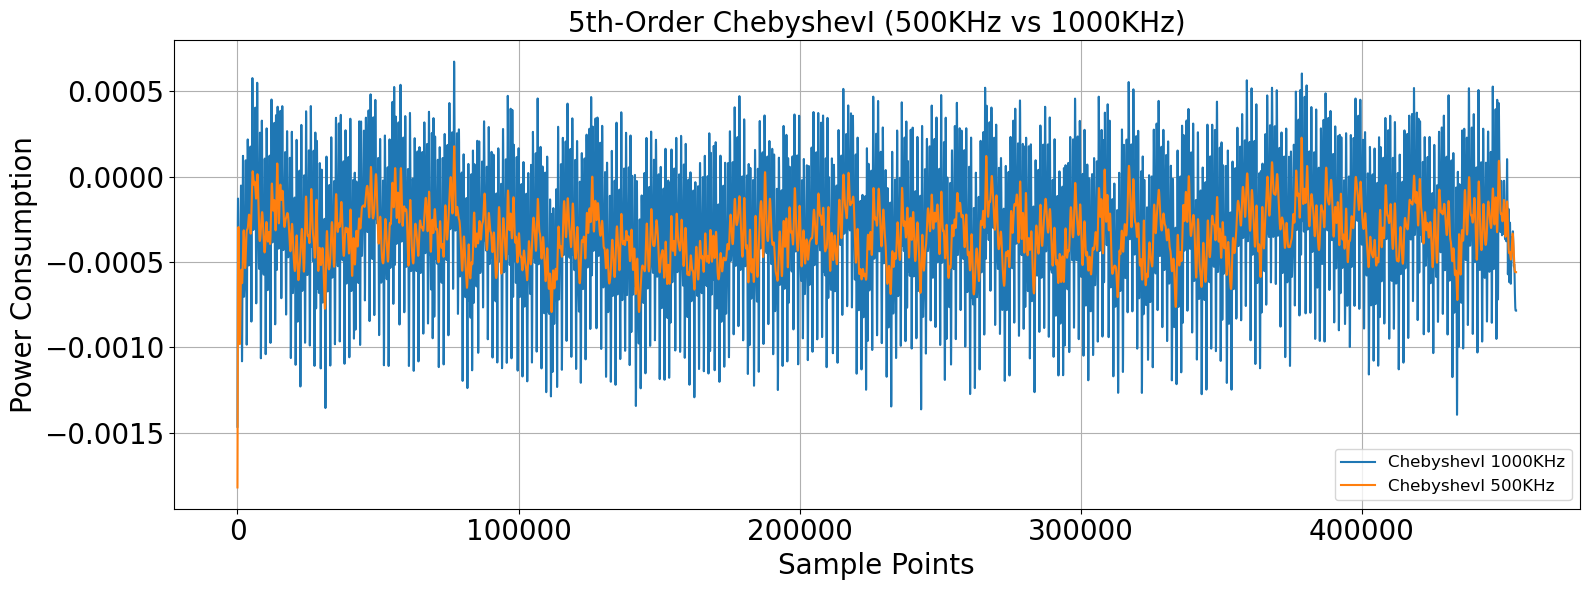

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 資料夾路徑設定
folders = {
    '1000KHz': 'traces_ChebyshevI_lowpass/cf1000K_order5',
    '500KHz':  'traces_ChebyshevI_lowpass/cf500K_order5',
}

TRACE_IDX = 0  # 選擇要畫的 trace 編號 (0 ~ 1999)

plt.figure(figsize=(16, 8))

for label, folder in folders.items():
    file_path = os.path.join(folder, 'trace.npy')
    if not os.path.isfile(file_path):
        print(f"Warning: 找不到 {file_path}")
        continue

    data = np.load(file_path)
    if data.ndim != 2 or TRACE_IDX >= data.shape[0]:
        print(f"Warning: {file_path} 形狀 {data.shape} 無法取第 {TRACE_IDX} 條")
        continue

    trace = data[TRACE_IDX]
    plt.plot(trace[100:], label=f'ChebyshevI {label}')
    
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.title('5th-Order ChebyshevI (500KHz vs 1000KHz)', fontsize=20)
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.grid(True)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.savefig(f'figure/chebyshev_lowpass/500vs1000.png', dpi=200, bbox_inches='tight')

plt.show()


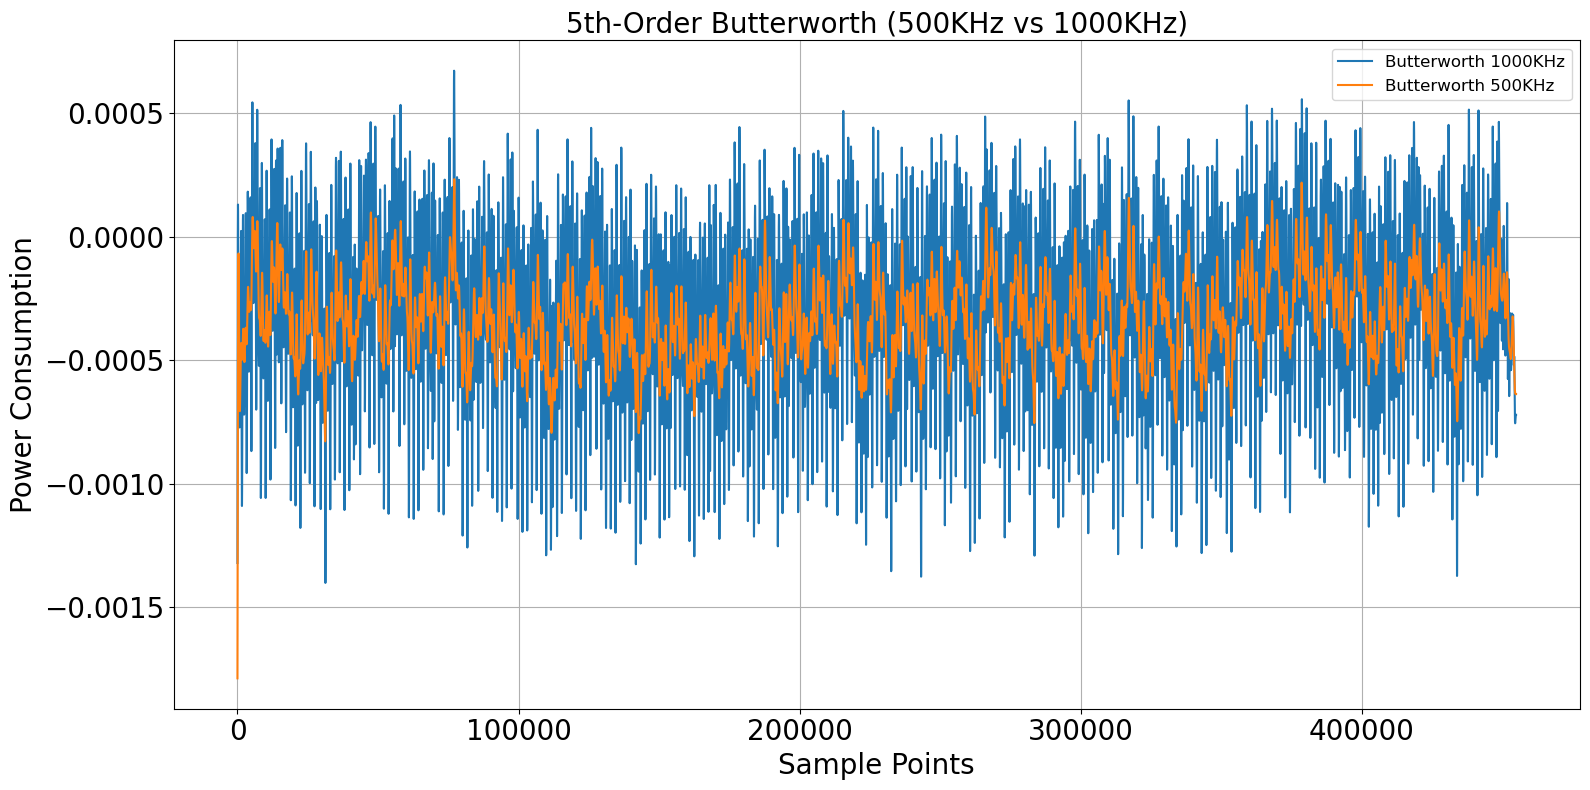

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 資料夾路徑設定
folders = {
    '1000KHz': 'traces_Butterworth_lowpass/cf1000K_order5',
    '500KHz':  'traces_Butterworth_lowpass/cf500K_order5',
}

TRACE_IDX = 0  # 選擇要畫的 trace 編號 (0 ~ 1999)

plt.figure(figsize=(16, 8))

for label, folder in folders.items():
    file_path = os.path.join(folder, 'trace.npy')
    if not os.path.isfile(file_path):
        print(f"Warning: 找不到 {file_path}")
        continue

    data = np.load(file_path)
    if data.ndim != 2 or TRACE_IDX >= data.shape[0]:
        print(f"Warning: {file_path} 形狀 {data.shape} 無法取第 {TRACE_IDX} 條")
        continue

    trace = data[TRACE_IDX]
    plt.plot(trace[100:], label=f'Butterworth {label}')
    
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.title('5th-Order Butterworth (500KHz vs 1000KHz)', fontsize=20)
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.grid(True)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.savefig(f'figure/butterworth_lowpass/500vs1000.png', dpi=200, bbox_inches='tight')

plt.show()
